In [ ]:
"""
Compare FEM wall-drag data with the Zeng parallel and Brenner
perpendicular corrections.
"""
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

plt.rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
    "font.size": 30,
    "axes.labelsize": 30,
    "xtick.labelsize": 30,
    "ytick.labelsize": 30,
    "legend.fontsize": 30,
    "lines.linewidth": 2,
    "axes.linewidth": 1,
})

import sys
from pathlib import Path

sys.path.insert(0, str(Path.cwd().parent))

from src.wall_corrections import WallCorrections

W = WallCorrections()

DATA_DIR = Path.cwd().parent / "data" / "fom_wall_data"

delta_par, lam_par_fem = np.loadtxt(DATA_DIR / "angle-0.txt").T

delta_perp, lam_perp_fem = np.loadtxt(DATA_DIR / "angle-90.txt").T

delta_grid = np.logspace(-2, 2, 200)

fig, axes = plt.subplots(1, 2, figsize=(16, 6), constrained_layout=True)

ax = axes[0]
ax.plot( delta_grid, W.zeng_parallel(delta_grid), color="tab:blue", label="Zeng et al. (2009)")
ax.plot(delta_par, lam_par_fem, "o", color="black", markersize=12, markerfacecolor="white", label=r"FOM ($\theta=0^\circ$)")
ax.set( xscale="log", xlim=(1e-2, 1e2), ylim=(1, 4), xlabel=r"$\delta/a$",ylabel=r"$f_\parallel$")
ax.set_xticks([1e-2, 1e-1, 1, 10, 100])
ax.set_yticks([1, 2, 3, 4])

ax = axes[1]
ax.loglog( delta_grid, W.brenner_perpendicular(delta_grid), color="tab:red", label="Brenner (1961)")
ax.loglog( delta_perp, lam_perp_fem, "s", color="black",  markersize=12,  markerfacecolor="white", label=r"FOM ($\theta=90^\circ$)")
ax.set( xlim=(1e-2, 1e2), ylim=(1, 1e2), xlabel=r"$\delta/a$", ylabel=r"$f_\perp$")
ax.set_xticks([1e-2, 1e-1, 1, 10, 100])
ax.set_yticks([1, 10, 100])

for ax in axes:
    ax.grid(True, alpha=0.3)
    ax.legend()

plt.savefig(DATA_DIR / "wall_correction.pdf")
plt.show()

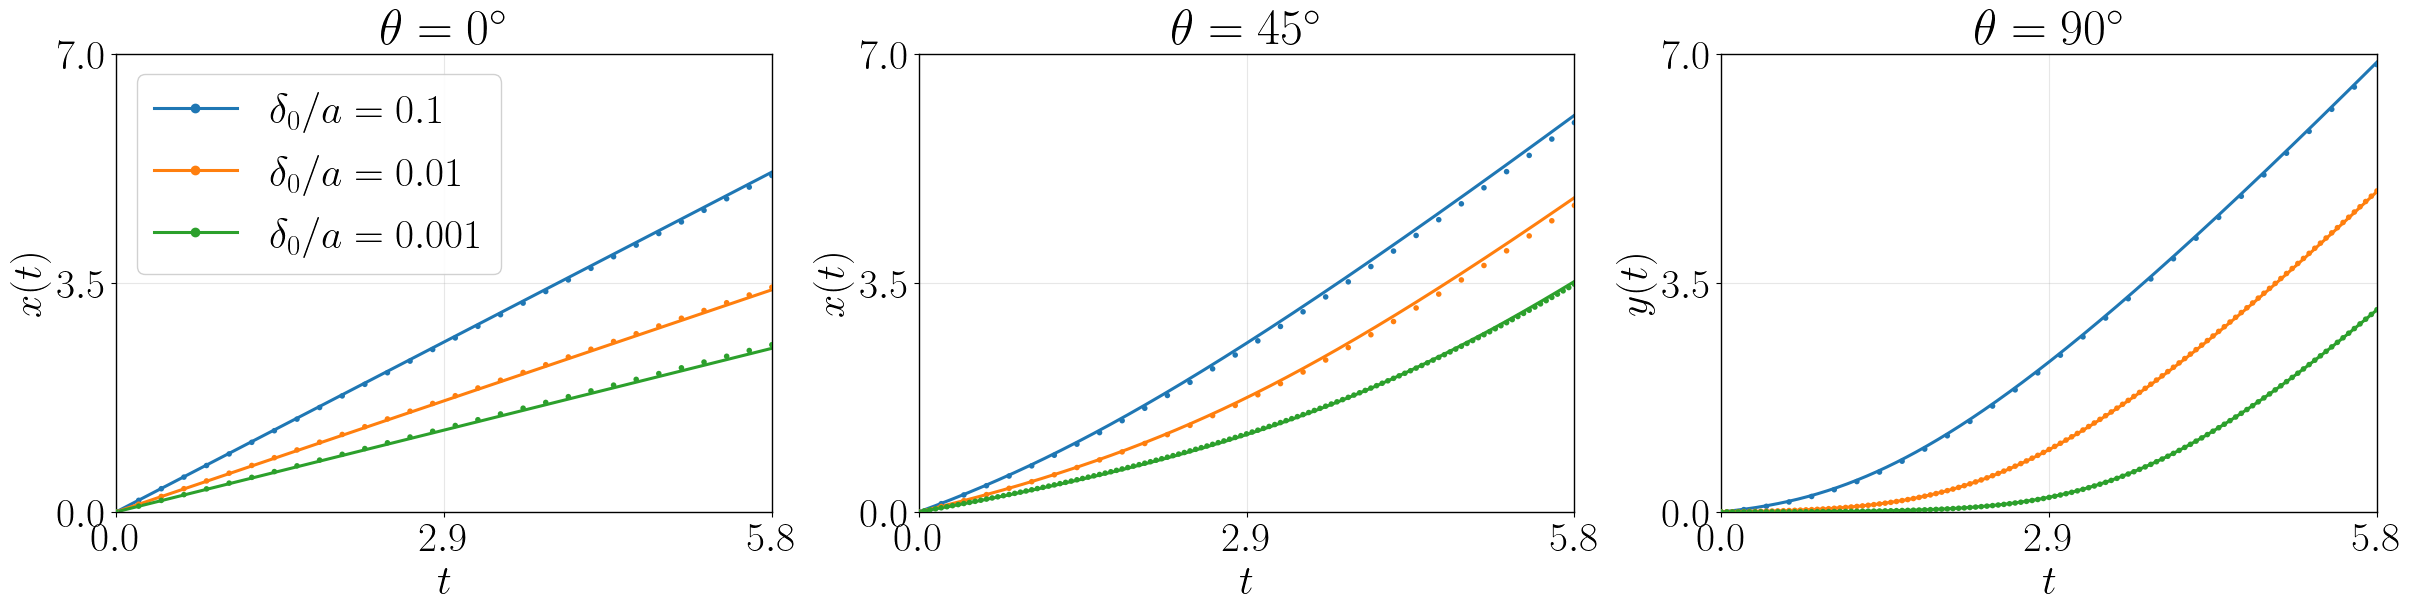

Saved plots to:
C:\Users\paraj\Documents\particle_inference_test\plots\newtonian_f12pi_delta_overlays


In [16]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
from matplotlib.lines import Line2D

ROOT = Path(r"C:\Users\paraj\Documents\particle_inference_test")
DATA_DIR = ROOT / "data" / "newtonian"
OUT_DIR = ROOT / "plots" / "newtonian_f12pi_delta_overlays"
sys.path.insert(0, str(ROOT))
from src.main import InferenceProcedure

FORCE = 12 * np.pi
ETA = 1.0
T_MAX = 5.8
ANGLES = (0, 45, 90)
DELTAS = (0.1, 0.01, 0.001)

plt.rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
    "font.size": 30,
    "axes.labelsize": 30,
    "xtick.labelsize": 30,
    "ytick.labelsize": 30,
    "legend.fontsize": 30,
    "lines.linewidth": 2,
    "axes.linewidth": 1,
})


def load_data(angle, delta):
    path = DATA_DIR / f"angle-{angle}" / f"delta-{delta:g}-{angle}.txt"
    t, x, y = np.loadtxt(path, usecols=(0, 1, 2)).T
    y -= y[0]
    keep = t <= T_MAX
    return t[keep], x[keep], y[keep]


def plot_angle(ax, model, angle, legend=False):
    colors = plt.cm.tab10.colors
    maximum = 0.0

    for i, delta in enumerate(DELTAS):
        t, x, y = load_data(angle, delta)
        obs = y if angle == 90 else x

        t_model = np.linspace(0, min(T_MAX, t.max()), 600)
        model.theta = angle
        pred = model.model_newtonian(ETA, t_model, FORCE, delta)

        ax.scatter(t, obs, s=16, color=colors[i], edgecolors="none", zorder=3)
        ax.plot(t_model, pred, color=colors[i], lw=2.2)

        maximum = max(maximum, np.nanmax(obs), np.nanmax(pred))

    ax.set(
        xlabel=r"$t$",
        ylabel=r"$y(t)$" if angle == 90 else r"$x(t)$",
        title=rf"$\theta={angle}^\circ$",
        xlim=(0, T_MAX),
        ylim=(0, maximum),
    )
    ax.set_xticks([0, T_MAX / 2, T_MAX])
    ax.set_yticks(np.linspace(0, maximum, 3))
    ax.grid(alpha=0.3)

    if legend:
        ax.legend(
            handles=[
                Line2D(
                    [0], [0],
                    color=colors[i],
                    marker="o",
                    lw=2.2,
                    label=rf"$\delta_0/a={delta:g}$",
                )
                for i, delta in enumerate(DELTAS)
            ],
            framealpha=0.9,
        )


def save_figure(fig, name):
    fig.savefig(OUT_DIR / f"{name}.pdf", bbox_inches="tight")
    fig.savefig(OUT_DIR / f"{name}.png", bbox_inches="tight")
    plt.close(fig)


def main():
    OUT_DIR.mkdir(parents=True, exist_ok=True)

    model = InferenceProcedure(
        force=FORCE,
        material_model="newtonian",
        boundary_model="bounded",
        theta=0,
        a=1.0,
        t_unload=None,
        sigma_noise_percent=None,
    )

    for angle in ANGLES:
        fig, ax = plt.subplots(figsize=(8, 6))
        plot_angle(ax, model, angle)
        save_figure(fig, f"newtonian_{angle}_delta_overlay")

    fig, axes = plt.subplots( 1, 3, figsize=(24, 6), constrained_layout=True)

    for i, (ax, angle) in enumerate(zip(axes, ANGLES)):
        plot_angle(ax, model, angle, legend=(i == 0))
        ax.set_ylim(0, 7)
        ax.set_yticks([0, 3.5, 7])

    plt.show()
    save_figure(fig, "delta_newtonian")
    print(f"Saved plots to:\n{OUT_DIR}")


if __name__ == "__main__":
    main()

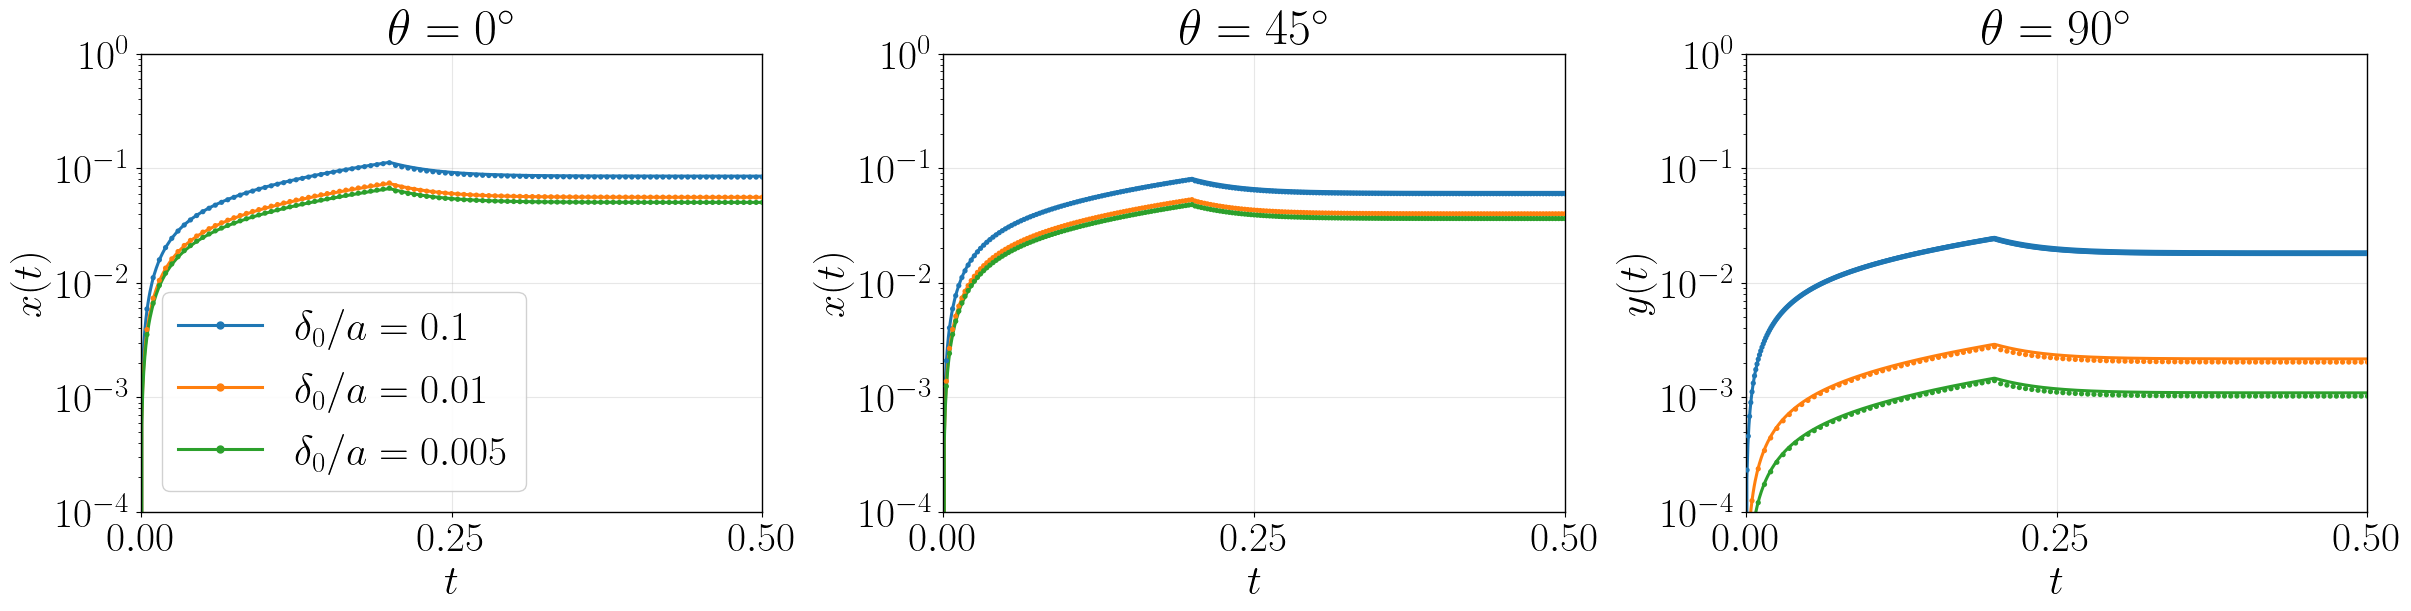

Saved plots to:
C:\Users\paraj\Documents\particle_inference_test\plots\linear_viscoelastic_delta_overlays


In [21]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
from matplotlib.lines import Line2D


# ---------------------------------------------------------------------
# Paths
# ---------------------------------------------------------------------
ROOT = Path(r"C:\Users\paraj\Documents\particle_inference_test")
DATA_DIR = ROOT / "data" / "linear_viscoelastic"
OUT_DIR = ROOT / "plots" / "linear_viscoelastic_delta_overlays"

if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from src.main import InferenceProcedure


# ---------------------------------------------------------------------
# Parameters
# ---------------------------------------------------------------------
FORCE = 8.0 * np.pi
ETA_S = 0.5
ETA_P = 0.9
LAMBDA = 0.1

T_UNLOAD = 0.2
T_MAX = 0.5

ANGLES = (0, 45, 90)
DELTAS = (0.1, 0.01, 0.005)
COLORS = plt.cm.tab10.colors

plt.rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
    "font.size": 30,
    "axes.labelsize": 30,
    "xtick.labelsize": 30,
    "ytick.labelsize": 30,
    "legend.fontsize": 30,
    "lines.linewidth": 2,
    "axes.linewidth": 1,
})


# ---------------------------------------------------------------------
# Data
# ---------------------------------------------------------------------
def load_data(angle: int, delta: float):
    path = (
        DATA_DIR
        / f"angle{angle}"
        / f"delta-{delta:g}-{angle}.out"
    )

    if not path.is_file():
        raise FileNotFoundError(f"Data file not found:\n{path}")

    t, x, y = np.loadtxt(path, usecols=(0, 1, 2)).T
    y = y - y[0]

    keep = t <= T_MAX
    return t[keep], x[keep], y[keep]


# ---------------------------------------------------------------------
# Plotting
# ---------------------------------------------------------------------
def plot_angle(
    ax: plt.Axes,
    model: InferenceProcedure,
    angle: int,
    show_legend: bool = False,
):
    maximum = 0.0

    for i, delta in enumerate(DELTAS):
        t, x, y = load_data(angle, delta)
        observation = y if angle == 90 else x

        t_model = np.linspace(0.0, min(T_MAX, t.max()), 600)

        model.theta = angle
        prediction = model.model_viscoelastic(
            ETA_S,
            ETA_P,
            LAMBDA,
            t_model,
            FORCE,
            delta,
        )

        ax.scatter(
            t,
            observation,
            s=14,
            color=COLORS[i],
            edgecolors="none",
            zorder=3,
        )
        ax.plot(
            t_model,
            prediction,
            color=COLORS[i],
            lw=2.2,
            zorder=2,
        )

        maximum = max(
            maximum,
            float(np.nanmax(observation)),
            float(np.nanmax(prediction)),
        )

    ax.set(
        xlabel=r"$t$",
        ylabel=r"$y(t)$" if angle == 90 else r"$x(t)$",
        title=rf"$\theta={angle}^\circ$",
        xlim=(0.0, T_MAX),
        ylim=(0.0, maximum if maximum > 0 else 1.0),
    )
    ax.set_xticks([0.0, 0.25, 0.5])
    ax.set_yticks(np.linspace(0.0, ax.get_ylim()[1], 3))
    ax.grid(alpha=0.3)

    if show_legend:
        handles = [
            Line2D(
                [0],
                [0],
                color=COLORS[i],
                marker="o",
                lw=2.2,
                markersize=5,
                label=rf"$\delta_0/a={delta:g}$",
            )
            for i, delta in enumerate(DELTAS)
        ]
        ax.legend(handles=handles, framealpha=0.9)


def save_figure(fig, filename: str):
    fig.savefig(OUT_DIR / f"{filename}.pdf", bbox_inches="tight")
    plt.close(fig)


# ---------------------------------------------------------------------
# Main
# ---------------------------------------------------------------------
def main():
    OUT_DIR.mkdir(parents=True, exist_ok=True)

    model = InferenceProcedure(
        force=FORCE,
        material_model="viscoelastic",
        boundary_model="bounded",
        theta=0,
        a=1.0,
        t_unload=T_UNLOAD,
        sigma_noise_percent=None,
    )

    # Separate plot for each angle
    for angle in ANGLES:
        fig, ax = plt.subplots(figsize=(8, 6))
        plot_angle(ax, model, angle, show_legend=True)
        save_figure(fig, f"viscoelastic_{angle}_delta_overlay")

    # All angles in one figure
    fig, axes = plt.subplots(
        1,
        3,
        figsize=(24, 6),
        constrained_layout=True,
    )

    for i, (ax, angle) in enumerate(zip(axes, ANGLES)):
        plot_angle(
            ax,
            model,
            angle,
            show_legend=(i == 0),
        )

        ax.set_yscale("log")
        ax.set_ylim(1e-4, 1)
        ax.set_yticks([1e-4, 1e-3, 1e-2, 1e-1, 1])
    plt.show()
    save_figure(fig, "viscoelastic_delta_theta")

    print(f"Saved plots to:\n{OUT_DIR}")


if __name__ == "__main__":
    main()

 L       Q(L)
  5    0.466050
 10    0.720459
 20    0.858659
 30    0.905578
 40    0.929133
 60    0.952731


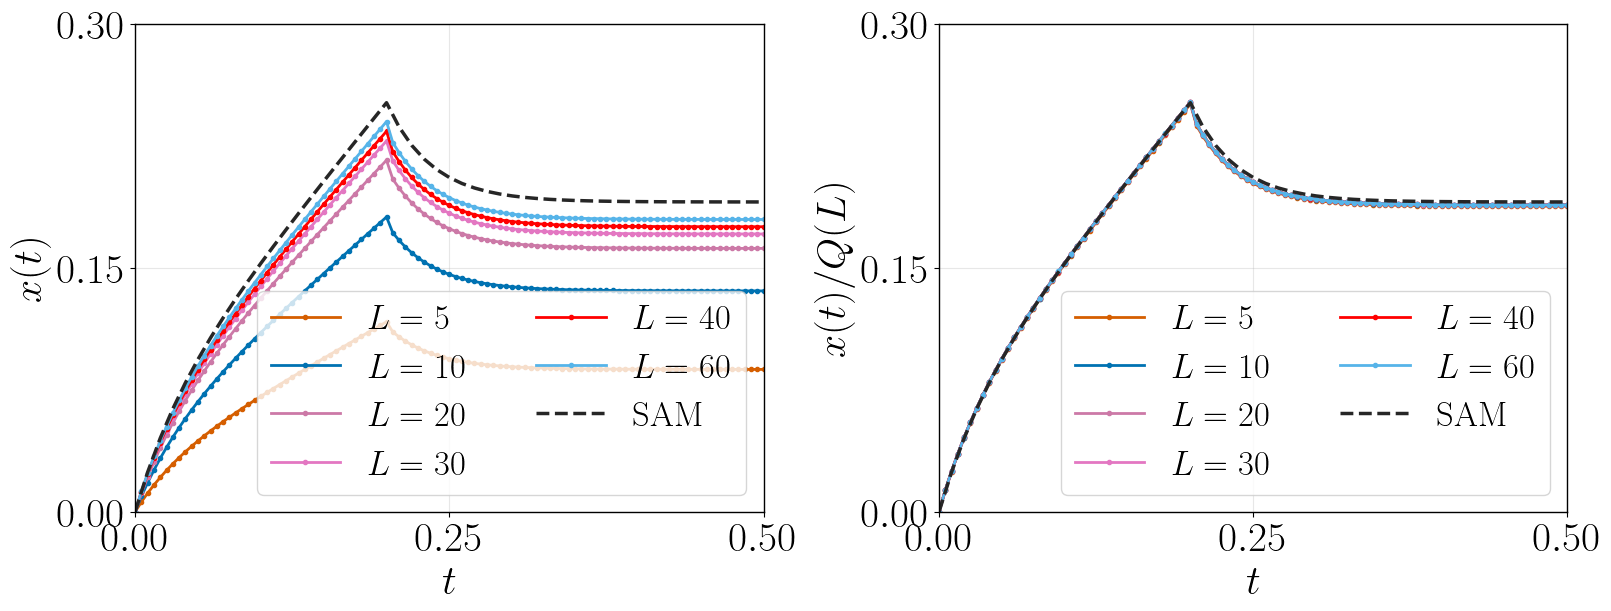

Saved plots to:
C:\Users\paraj\Documents\particle_inference_test\plots\particle-particle


In [25]:
"""
Domain-convergence plots for triperiodic Stokes simulations.

Data location:
C:/Users/paraj/Documents/particle_inference_test/data/particle-particle/

Expected files:
    lx_five.out, lx_ten.out, lx-20.out, ...
    analytical_model.txt

Simulation columns:
    0:t, 1:x, 2:y, 3:z, 4:Ux, 5:Uy, 6:Uz, ...

Analytical columns:
    0:t, 1:x_model, 2:Ux_model
"""

from pathlib import Path
import re

import matplotlib.pyplot as plt
import numpy as np


# ---------------------------------------------------------------------
# Paths and settings
# ---------------------------------------------------------------------
ROOT = Path(r"C:\Users\paraj\Documents\particle_inference_test")
DATA_DIR = ROOT / "data" / "particle-particle"
OUT_DIR = ROOT / "plots" / "particle-particle"

T_COL, X_COL, V_COL = 0, 1, 4
AM_T, AM_X, AM_V = 0, 1, 2
A_RADIUS = 1.0

NAME_TO_SIZE = {
    "five": 5,
    "ten": 10,
    "twenty": 20,
    "thirty": 30,
    "forty": 40,
    "fourty": 40,
    "sixty": 60,
}

DOMAIN_COLORS = {
    5: "#D55E00",
    10: "#0072B2",
    20: "#CC79A7",
    40: "red",
    60: "#56B4E9",
}

plt.rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
    "font.size": 30,
    "axes.labelsize": 30,
    "xtick.labelsize": 30,
    "ytick.labelsize": 30,
    "legend.fontsize": 25,
    "lines.linewidth": 2,
    "axes.linewidth": 1,
})


# ---------------------------------------------------------------------
# Data
# ---------------------------------------------------------------------
def discover_boxes():
    """Return {box size: file path} for lx_<name>.out or lx-<size>.out."""
    files = {}

    for path in DATA_DIR.glob("lx*.out*"):
        match = re.match(r"lx[_-]([^.]+)", path.name, re.IGNORECASE)
        if not match:
            continue

        token = match.group(1).lower()

        try:
            size = int(token)
        except ValueError:
            size = NAME_TO_SIZE.get(token)

        if size is not None:
            files[size] = path

    if not files:
        raise FileNotFoundError(f"No lx_*.out or lx-*.out files found in:\n{DATA_DIR}")

    return dict(sorted(files.items()))


BOX_PATHS = discover_boxes()
BOXES = tuple(BOX_PATHS)

fallback = plt.cm.tab10(np.linspace(0, 1, len(BOXES)))
COLORS = {
    size: DOMAIN_COLORS.get(size, fallback[i])
    for i, size in enumerate(BOXES)
}


def load_box(size):
    return np.loadtxt(BOX_PATHS[size], ndmin=2)


def load_analytical():
    path = DATA_DIR / "analytical_model.txt"
    return np.loadtxt(path, ndmin=2) if path.is_file() else None


def hasimoto_q(size, radius=A_RADIUS):
    ratio = radius / size
    return 1 - 2.8373 * ratio + (4 * np.pi / 3) * ratio**3


def save_figure(fig, name):
    OUT_DIR.mkdir(parents=True, exist_ok=True)
    fig.savefig(OUT_DIR / f"{name}.pdf", bbox_inches="tight")
    fig.savefig(OUT_DIR / f"{name}.png", bbox_inches="tight")
    plt.close(fig)


# ---------------------------------------------------------------------
# Raw velocity and displacement
# ---------------------------------------------------------------------
def plot_raw(analytical):
    fig, axes = plt.subplots(
        1,
        2,
        figsize=(16, 6),
        constrained_layout=True,
    )

    for size in BOXES:
        data = load_box(size)
        time = data[:, T_COL]
        color = COLORS[size]

        axes[0].plot(
            time,
            data[:, V_COL],
            "-o",
            ms=3,
            color=color,
            label=rf"$L={size}$",
        )
        axes[1].plot(
            time,
            data[:, X_COL],
            "-o",
            ms=3,
            color=color,
            label=rf"$L={size}$",
        )

    if analytical is not None:
        axes[0].plot(
            analytical[:, AM_T],
            analytical[:, AM_V],
            "--",
            color="0.15",
            lw=2.5,
            label="SAM",
        )
        axes[1].plot(
            analytical[:, AM_T],
            analytical[:, AM_X],
            "--",
            color="0.15",
            lw=2.5,
            label="SAM",
        )

    axes[0].set_ylabel(r"$U_x(t)$")
    axes[1].set_ylabel(r"$x(t)$")

    for ax in axes:
        ax.set_xlabel(r"$t$")
        ax.grid(alpha=0.3)
        ax.legend()

    save_figure(fig, "domain_conv_raw")


# ---------------------------------------------------------------------
# Raw and Hasimoto-corrected displacement
# ---------------------------------------------------------------------
def plot_corrected(analytical):
    fig, axes = plt.subplots(
        1,
        2,
        figsize=(16, 6),
        constrained_layout=True,
    )

    print(" L       Q(L)")

    for size in BOXES:
        data = load_box(size)
        time = data[:, T_COL]
        displacement = data[:, X_COL]
        q_value = hasimoto_q(size)
        color = COLORS[size]

        print(f"{size:3d}    {q_value:.6f}")

        axes[0].plot(
            time,
            displacement,
            "-o",
            ms=3,
            color=color,
            label=rf"$L={size}$",
        )
        axes[1].plot(
            time,
            displacement / q_value,
            "-o",
            ms=3,
            color=color,
            label=rf"$L={size}$",
        )

    if analytical is not None:
        for ax in axes:
            ax.plot(
                analytical[:, AM_T],
                analytical[:, AM_X],
                "--",
                color="0.15",
                lw=2.5,
                label="SAM",
            )

    axes[0].set_ylabel(r"$x(t)$")
    axes[1].set_ylabel(r"$x(t)/Q(L)$")

    for ax in axes:
        ax.set(
            xlabel=r"$t$",
            xlim=(0, 0.5),
            ylim=(0, 0.3),
        )
        ax.set_xticks([0, 0.25, 0.5])
        ax.set_yticks([0, 0.15, 0.3])
        ax.grid(alpha=0.3)
        ax.legend(ncols=2)
    plt.show()
    save_figure(fig, "domain_conv_hasimoto")

def main():
    analytical = load_analytical()

    plot_raw(analytical)
    plot_corrected(analytical)

    print(f"Saved plots to:\n{OUT_DIR}")

if __name__ == "__main__":
    main()